# Synthetic Datasets — Spectral Clustering Benchmark

**COMP702 Dissertation · Milestone 1**

This notebook benchmarks five clustering algorithms on three synthetic datasets
with known ground truth, following the project methodology end-to-end:

| Algorithm | Reference |
|---|---|
| K-Means (baseline) | Lloyd (1957) |
| Unnormalised Spectral Clustering | von Luxburg (2007) |
| Normalised SC — Shi & Malik | Shi & Malik (2000) |
| Normalised SC — Ng, Jordan & Weiss | Ng, Jordan & Weiss (2001) |
| Self-Tuning SC — Zelnik-Manor & Perona | Zelnik-Manor & Perona (2004) |

**Datasets:** concentric rings, two moons, three blobs (scikit-learn generators).

**Pipeline for each subset:**
1. Build a fully-connected Gaussian **RBF affinity graph** with the **median-heuristic** bandwidth sigma.
2. Choose *k* — **elbow** method for K-Means; a **two-step** procedure for the spectral methods (candidate shortlist from the eigenvalue spectrum, then disambiguation by clustering quality).
3. Run all five algorithms with a **fixed seed** (`numpy` seed 42, `sklearn` `n_init=10`).
4. Score with **ARI** and **NMI** against ground truth.
5. Export results to `results/synthetic.json` for the Next.js visualiser.

All heavy lifting lives in the reusable `scripts/` package so the notebook stays
readable and the logic is shared with the other dataset notebooks.


In [1]:
import sys
from pathlib import Path

# make the repo root importable whether the notebook is launched from
# notebooks/ or from the repo root
_here = Path.cwd()
_repo = _here if (_here / "scripts").exists() else _here.parent
sys.path.insert(0, str(_repo))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts import SEED
from scripts.datasets import make_synthetic
from scripts.graphs import rbf_affinity, median_heuristic
from scripts.selection import (
    kmeans_elbow, eigengap, suggest_k_candidates, pick_best_k, select_spectral_k,
)
from scripts.spectral import ALGORITHMS, self_tuning_spectral
from scripts.metrics import supervised_metrics

np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110
print(f"Global seed = {SEED}")
print("Algorithms:", ", ".join(a["label"] for a in ALGORITHMS.values()))

Global seed = 42
Algorithms: K-Means (baseline), Unnormalised SC, Normalised SC — Shi & Malik (2000), Normalised SC — Ng, Jordan & Weiss (2001), Self-Tuning SC — Zelnik-Manor & Perona (2004)


## 1. Generate the synthetic datasets

Each dataset is standardised (zero mean, unit variance) and seeded so it is
identical on every run.

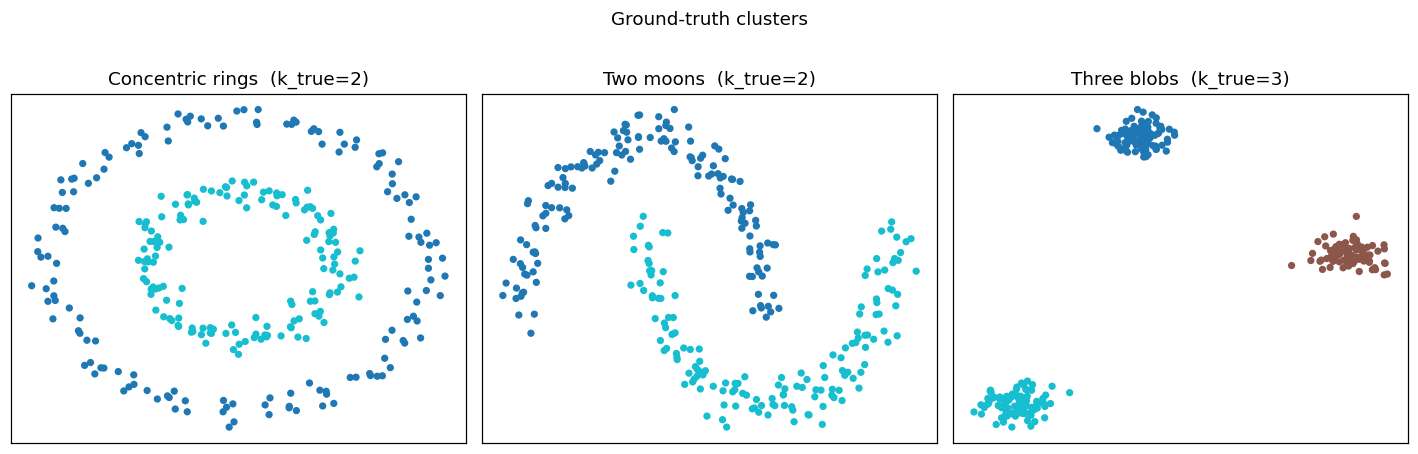

In [2]:
data = make_synthetic(n_samples=300, seed=SEED)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, ds) in zip(axes, data.items()):
    ax.scatter(ds["X"][:, 0], ds["X"][:, 1], c=ds["y"], cmap="tab10", s=14)
    ax.set_title(f'{ds["label"]}  (k_true={ds["k_true"]})')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Ground-truth clusters", y=1.02)
plt.tight_layout(); plt.show()

## 2. Similarity graph — RBF kernel with the median heuristic

For point set $X$ the fully-connected Gaussian affinity is

$$W_{ij} = \exp\!\left(-\frac{\lVert x_i - x_j\rVert^2}{2\sigma^2}\right),\qquad
\sigma = \operatorname{median}\big(\lVert x_i - x_j\rVert\big).$$

The median heuristic is a parameter-free, data-driven choice for sigma.

rings : sigma (median heuristic) = 1.7525
moons : sigma (median heuristic) = 1.7459
blobs : sigma (median heuristic) = 1.9637


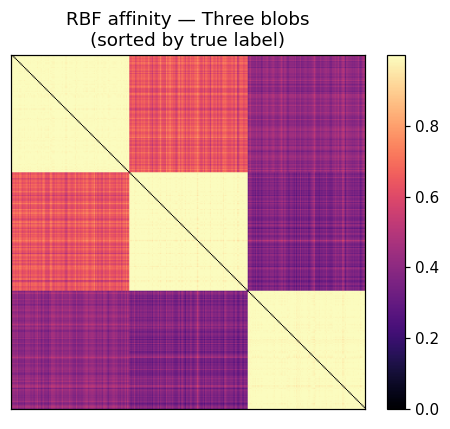

In [3]:
sigmas = {}
for name, ds in data.items():
    W, sigma = rbf_affinity(ds["X"])
    ds["W"] = W
    sigmas[name] = sigma
    print(f"{name:6s}: sigma (median heuristic) = {sigma:.4f}")

# visualise one affinity matrix (rows/cols sorted by ground-truth label)
name = "blobs"
order = np.argsort(data[name]["y"])
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(data[name]["W"][np.ix_(order, order)], cmap="magma")
ax.set_title(f'RBF affinity — {data[name]["label"]}\n(sorted by true label)')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## 3. Choosing *k*

**K-Means -> elbow method.** Plot within-cluster inertia against *k* and pick the
point of maximum curvature (largest perpendicular distance to the chord joining
the endpoints).

**Spectral -> two-step selection.** The classic *single-largest-gap* eigengap
rule is systematically biased toward **k = 2**: every connected graph's Laplacian
has an eigenvalue at (or near) zero, so the first gap away from zero tends to be
the largest in absolute terms regardless of the true number of clusters
(von Luxburg, 2007, §8.3). On our `blobs` set (true *k* = 3) the naive rule
always returns *k* = 2. We therefore use a two-step procedure:

1. **Shortlist candidates** — take the `top_n` largest eigenvalue gaps (within a
   sensible range 2 ≤ *k* ≤ 8) as plausible cluster counts
   (`suggest_k_candidates`).
2. **Disambiguate by quality** — cluster at each candidate and keep the *k* with
   the best downstream score: **ARI** here (ground truth is available), or
   **Silhouette** for the unlabelled network datasets (`pick_best_k`). The
   reference partition is **self-tuning** spectral clustering, whose local
   scaling best reflects the intrinsic structure; the chosen *k* is then applied
   uniformly to every spectral method.

Below, the naive single-gap estimate (orange) is shown alongside the candidate
shortlist (blue dotted) and the two-step choice (red).

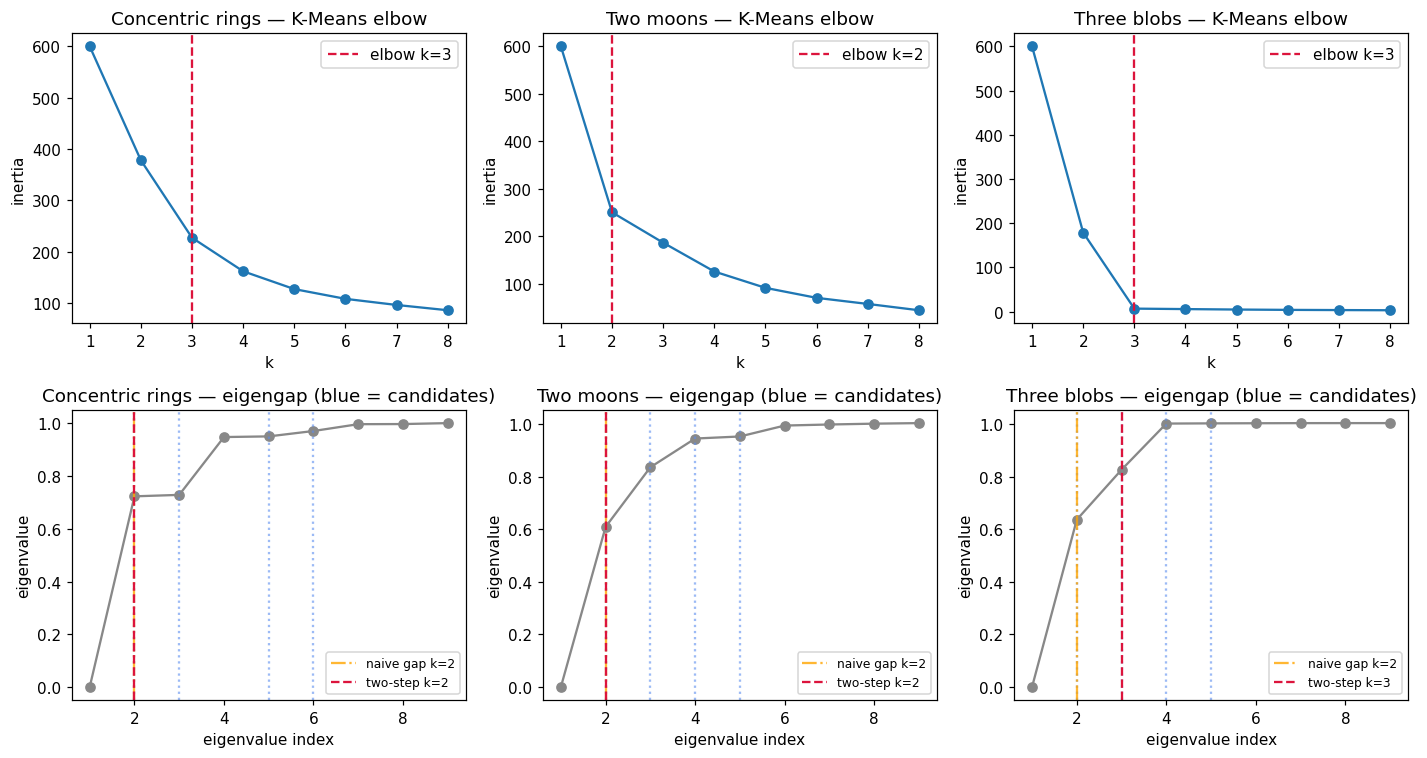

rings : elbow k=3, naive-gap k=2, candidates=[3, 6, 5, 2], two-step k=2 (ARI {3: 0.749, 6: 0.331, 5: 0.309, 2: 1.0}), k_true=2
moons : elbow k=2, naive-gap k=2, candidates=[2, 3, 5, 4], two-step k=2 (ARI {2: 1.0, 3: 0.749, 5: 0.427, 4: 0.501}), k_true=2
blobs : elbow k=3, naive-gap k=2, candidates=[2, 3, 4, 5], two-step k=3 (ARI {2: 0.57, 3: 1.0, 4: 0.87, 5: 0.729}), k_true=3


In [4]:
selection = {}
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for j, (name, ds) in enumerate(data.items()):
    X, y, W = ds["X"], ds["y"], ds["W"]
    elbow = kmeans_elbow(X, k_range=range(1, 9))
    spec = select_spectral_k(
        W, X,
        reference_fn=lambda k, X=X: self_tuning_spectral(X, k),
        ground_truth=y, top_n=4, k_min=2, k_max=8,
    )
    selection[name] = {"elbow": elbow, "spectral": spec,
                       "k_kmeans": elbow["suggested_k"], "k_spectral": spec["best_k"]}

    ax = axes[0, j]
    ax.plot(elbow["k"], elbow["inertia"], "o-")
    ax.axvline(elbow["suggested_k"], color="crimson", ls="--",
               label=f'elbow k={elbow["suggested_k"]}')
    ax.set_title(f'{ds["label"]} — K-Means elbow')
    ax.set_xlabel("k"); ax.set_ylabel("inertia"); ax.legend()

    ax = axes[1, j]
    ev = spec["eigenvalues"]
    ax.plot(range(1, len(ev) + 1), ev, "o-", color="#888")
    for c in spec["candidates"]:
        ax.axvline(c, color="#5b8def", ls=":", alpha=0.6)
    ax.axvline(spec["naive_suggested_k"], color="orange", ls="-.", alpha=0.8,
               label=f'naive gap k={spec["naive_suggested_k"]}')
    ax.axvline(spec["best_k"], color="crimson", ls="--",
               label=f'two-step k={spec["best_k"]}')
    ax.set_title(f'{ds["label"]} — eigengap (blue = candidates)')
    ax.set_xlabel("eigenvalue index"); ax.set_ylabel("eigenvalue")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for name in data:
    s = selection[name]["spectral"]
    scores = {k: round(v, 3) for k, v in s["scores"].items()}
    print(f'{name:6s}: elbow k={selection[name]["k_kmeans"]}, '
          f'naive-gap k={s["naive_suggested_k"]}, candidates={s["candidates"]}, '
          f'two-step k={s["best_k"]} ({s["criterion"]} {scores}), '
          f'k_true={data[name]["k_true"]}')

The naive single-gap rule returns **k = 2** for all three datasets. The
two-step method recovers the correct counts: **k = 2** for rings and moons,
**k = 3** for blobs — the candidate shortlist contains the true *k*, and the ARI
disambiguation selects it.

## 3b. Validation — is Silhouette-based k-selection trustworthy?

On the real-world datasets (Airports, Yeast PPI, Facebook) there is **no ground
truth**, so the two-step selection must disambiguate candidate *k* with the
**Silhouette Score** rather than ARI. Before relying on it there, we validate it
here on the synthetic data, where the true *k* is known: we rerun the *same*
two-step selection but swap the criterion to Silhouette (`ground_truth=None`),
and compare the chosen *k* against both the true *k* and the ARI-based choice.

Silhouette is computed on the standardised feature matrix, exactly as
`select_spectral_k` does when no labels are supplied. This is a **diagnostic
only** — ARI remains the primary criterion everywhere else in this notebook and
in `scripts.run_synthetic`.

In [5]:
from scripts.validate_kselection import silhouette_vs_ari

# reruns the two-step selection with ARI and with Silhouette, prints the table
results = silhouette_vs_ari()

dataset  true_k  k_via_ARI  k_via_Silhouette  match?
----------------------------------------------------
rings    2       2          6                 NO
moons    2       2          5                 NO
blobs    3       3          3                 yes

VERDICT: Silhouette matches the true k on ['blobs'] but DISAGREES on ['rings', 'moons'].
         Silhouette rewards compact/convex clusters, so it is a biased criterion
         for non-convex structure. On the unlabelled real datasets, treat
         Silhouette-selected k as a guide only and cross-check it against the
         eigengap candidate shortlist (and, where possible, cluster stability).


### Interpretation

Read the `match?` column in the table above.

- **Blobs (convex, isotropic).** Silhouette measures within-cluster versus
  nearest-other-cluster distance in feature space, so it rewards compact,
  well-separated clusters. Blobs are exactly that, so Silhouette agrees with ARI
  and the true *k* = 3 here — Silhouette is reliable for this kind of structure.
- **Rings / moons (non-convex).** The *correct* partition groups points into
  interleaved, non-compact clusters (concentric rings; nested crescents). In
  Euclidean feature space those clusters are not compact, so Silhouette can score
  the true grouping *below* a more compact but wrong split — wherever the
  `match?` column shows a disagreement, this is the cause.

**Limitation to discuss in the dissertation.** Silhouette is a *biased* internal
criterion: it presupposes convex, compact clusters and therefore cannot be
trusted to select *k* for non-convex structure the way ARI can when labels exist.
Two consequences for the real-world datasets:

1. Where ground truth is unavailable, a Silhouette-selected *k* should be treated
   as a **guide, not ground truth** — cross-check it against the eigengap
   candidate shortlist and, where feasible, cluster stability or modularity.
2. **The space matters.** On the networks, Silhouette will be computed on the
   *spectral embedding* (there is no raw feature space), where well-separated
   communities are far more compact than concentric rings are in the plane. So
   Silhouette is likely *more* reliable there than this worst-case synthetic test
   suggests — but the convexity bias still applies, so the confidence ARI gives
   us here does not transfer automatically.

## 4. Run every algorithm and score it

K-Means uses the elbow *k*; the spectral methods use the two-step *k*. Metrics
are ARI and NMI against ground truth (both higher-is-better).

In [6]:
rows = []
predictions = {}   # (name, algo_key) -> labels, for the plots below
for name, ds in data.items():
    X, y, W = ds["X"], ds["y"], ds["W"]
    k_kmeans = selection[name]["k_kmeans"]
    k_spectral = selection[name]["k_spectral"]
    for key, spec in ALGORITHMS.items():
        k = k_kmeans if key == "kmeans" else k_spectral
        labels = spec["fn"](X, k) if spec["input"] == "X" else spec["fn"](W, k)
        predictions[(name, key)] = labels
        m = supervised_metrics(y, labels)
        rows.append({"dataset": name, "algorithm": spec["label"],
                     "k_used": k, "ARI": m["ARI"], "NMI": m["NMI"]})

results_df = pd.DataFrame(rows)
results_df.round(3)

,dataset,algorithm,k_used,ARI,NMI
0,rings,K-Means (baseline),3,-0.004,0.000
1,rings,Unnormalised SC,2,-0.003,0.000
2,rings,Normalised SC — Shi & Malik (2000),2,-0.003,0.000
3,rings,"Normalised SC — Ng, Jordan & Weiss (2001)",2,-0.003,0.000
4,rings,Self-Tuning SC — Zelnik-Manor & Perona (2004),2,1.000,1.000
5,moons,K-Means (baseline),2,0.479,0.382
6,moons,Unnormalised SC,2,0.470,0.374
7,moons,Normalised SC — Shi & Malik (2000),2,0.479,0.382
8,moons,"Normalised SC — Ng, Jordan & Weiss (2001)",2,0.479,0.382
9,moons,Self-Tuning SC — Zelnik-Manor & Perona (2004),2,1.000,1.000


### ARI heatmap (algorithm x dataset)

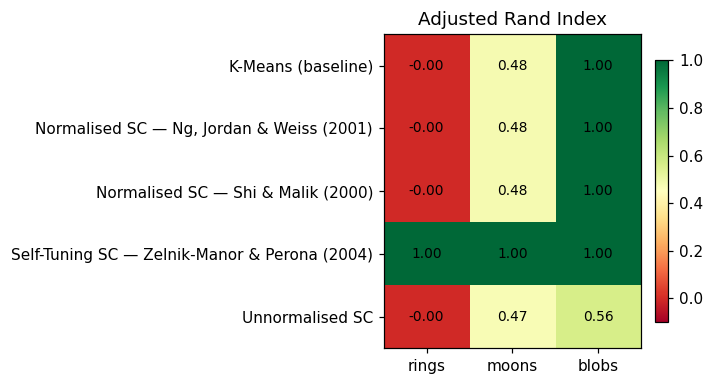

In [7]:
pivot = results_df.pivot(index="algorithm", columns="dataset", values="ARI")
pivot = pivot[["rings", "moons", "blobs"]]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-0.1, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Adjusted Rand Index"); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

## 5. Visualise the cluster assignments

Rows = algorithms, columns = datasets. Compare against the ground-truth row at
the top.

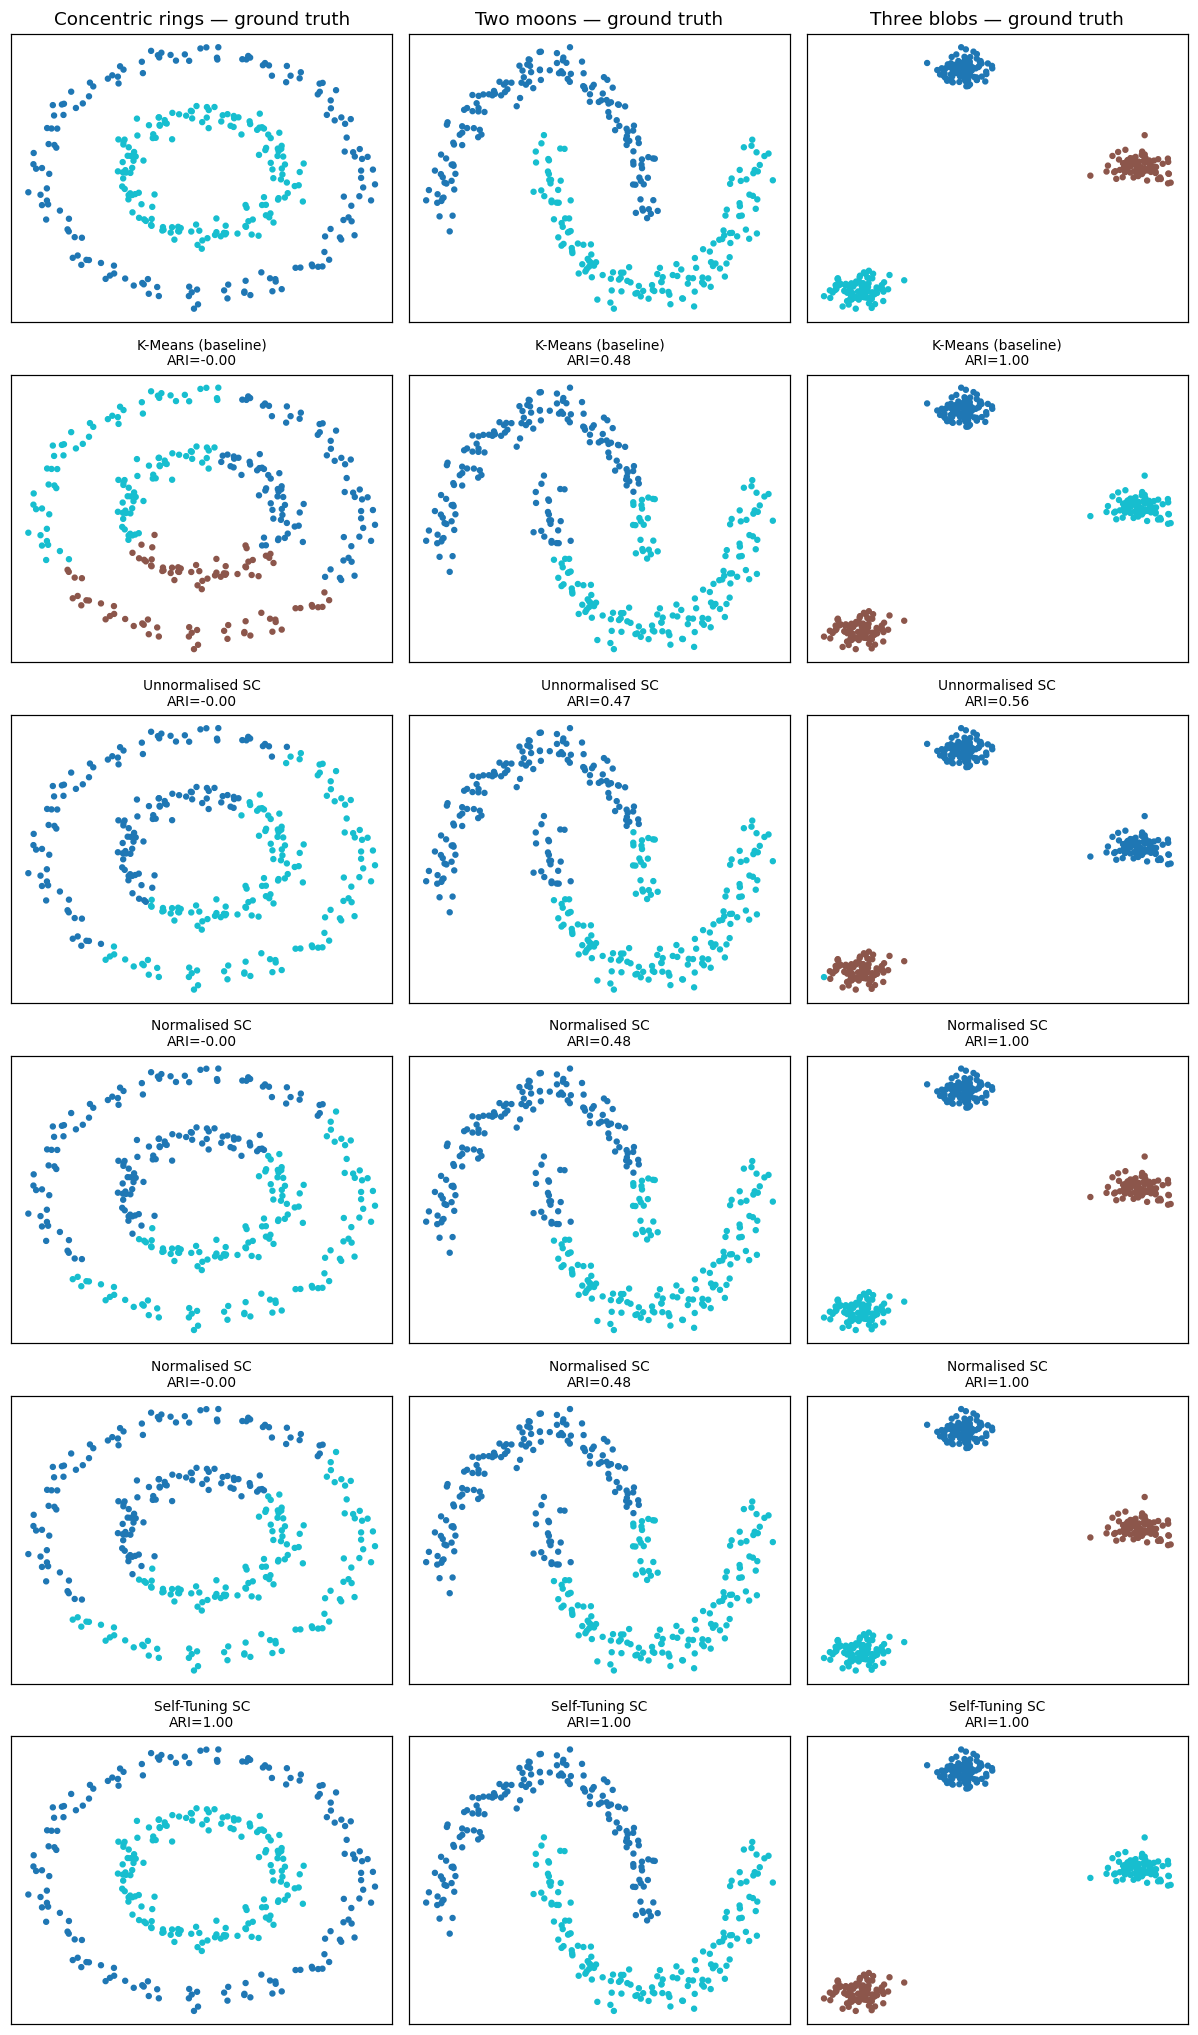

In [8]:
algo_keys = list(ALGORITHMS.keys())
n_rows = len(algo_keys) + 1
fig, axes = plt.subplots(n_rows, 3, figsize=(11, 3.1 * n_rows))

for j, name in enumerate(["rings", "moons", "blobs"]):
    ds = data[name]
    axes[0, j].scatter(ds["X"][:, 0], ds["X"][:, 1], c=ds["y"], cmap="tab10", s=10)
    axes[0, j].set_title(f'{ds["label"]} — ground truth')
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])

for i, key in enumerate(algo_keys, start=1):
    for j, name in enumerate(["rings", "moons", "blobs"]):
        ds = data[name]
        labels = predictions[(name, key)]
        ari = supervised_metrics(ds["y"], labels)["ARI"]
        ax = axes[i, j]
        ax.scatter(ds["X"][:, 0], ds["X"][:, 1], c=labels, cmap="tab10", s=10)
        ax.set_title(f'{ALGORITHMS[key]["label"].split(" — ")[0]}\nARI={ari:.2f}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. Export results for the visualiser

Writes `results/synthetic.json` in the schema the Next.js dashboard and dataset
explorer consume (points, ground truth, per-algorithm labels, metrics, and the
k-selection diagnostics including the candidate shortlist and disambiguation
scores). We reuse the canonical `scripts.run_synthetic` pipeline so the notebook
and the reproducible script always produce identical output.

In [9]:
from scripts.run_synthetic import run
payload = run(verbose=False)
print("Exported results/synthetic.json")
sel = payload["subsets"]["blobs"]["selection"]["spectral"]
print("blobs spectral selection:",
      "candidates", sel["candidates"], "-> k", sel["best_k"], f"({sel['criterion']})")

Exported results/synthetic.json
blobs spectral selection: candidates [2, 3, 4, 5] -> k 3 (ARI)


## 7. Findings

- **k-selection matters.** The naive single-largest-gap eigengap rule returns
  *k* = 2 for every dataset and so **under-clusters blobs**, capping the
  normalised spectral methods at ARI ≈ 0.57. The two-step method recovers
  *k* = 3, and Shi & Malik and Ng-Jordan-Weiss then partition blobs **perfectly
  (ARI = 1.0)**. This is the headline effect of the fix.
- **Non-convex shapes (rings, moons).** With the fully-connected RBF graph and a
  single global median-heuristic sigma, K-Means and the three global-bandwidth
  spectral methods still cannot separate the interleaved structure; only
  **Self-Tuning SC**, whose *local* per-point scale adapts to density, recovers
  the true clusters (ARI ≈ 1.0). This reproduces the classic motivation for
  local scaling (Zelnik-Manor & Perona, 2004).
- **Unnormalised vs normalised.** Even at the correct *k* = 3, *unnormalised*
  spectral clustering lags on blobs (ARI ≈ 0.57) while the normalised variants
  reach 1.0 — consistent with von Luxburg's (2007) recommendation to prefer
  normalised Laplacians.
- **Methodological note.** The single-largest-gap heuristic's bias toward *k* = 2
  is a known, citable limitation (von Luxburg, 2007, §8.3), not an artefact of
  this implementation. A **k-nearest-neighbour** RBF graph
  (`scripts.graphs.knn_rbf_affinity`) is available as a drop-in alternative that
  typically sharpens the eigengaps further.

Next milestone: apply the same pipeline (and the same two-step k-selection, with
Silhouette disambiguation since there is no ground truth) to the US Airport
Network dataset.


## 8. Davies-Bouldin under three embeddings (multi-embedding analysis)

This section adds a **Davies-Bouldin Index** analysis using the *same* three-
embedding framework applied to the real network datasets
(`scripts.network_eval.evaluate_multi_embedding`), so the methodology is
identical. The existing ARI/NMI evaluation above is unchanged — this runs
alongside it.

For each synthetic dataset we score all five algorithms' clusterings under three
embeddings of the **RBF affinity graph from Section 2**:

- **Unnormalised Laplacian** eigenvectors,
- **Symmetric normalised Laplacian** ($L_{sym}$) eigenvectors,
- **Shortest-path** distance on the similarity graph, via classical MDS.

One methodological note: the RBF affinity graph is *fully connected*, so an
unweighted hop distance would be a degenerate all-ones. For the shortest-path
embedding we therefore convert affinity to edge length via $-\log W_{ij}$ (which
for a Gaussian RBF is a monotone function of Euclidean distance) before running
shortest paths — handled by `similarity_graph=True`. The two Laplacian embeddings
are exactly as for the network datasets. Results are saved to
`results/network_eval_synthetic.json` in the same schema as
`network_eval_airports.json` / `_yeast.json` / `_facebook.json`.

In [10]:
import json
from scripts.network_eval import (
    evaluate_multi_embedding, ranking_consistency, consistency_verdict,
    format_comparison_table,
)

synth_multi = {}
for name, ds in data.items():
    W = ds["W"]
    # reuse the exact cluster assignments computed for the ARI/NMI analysis above
    labels_by_algo = {ALGORITHMS[key]["label"]: predictions[(name, key)]
                      for key in ALGORITHMS}
    df, timings = evaluate_multi_embedding(
        W, labels_by_algo, n_components=10, similarity_graph=True)

    print(f"\n=== {ds['label']} (k_true={ds['k_true']}) ===")
    print("Davies-Bouldin Index by embedding (lower is better):")
    print(format_comparison_table(df, "davies_bouldin").to_string(index=False))

    out = {"n": int(W.shape[0]), "complete_graph": True, "k_true": int(ds["k_true"]),
           "table": df.round(4).to_dict(orient="records"), "consistency": {}}
    for metric in ("davies_bouldin", "silhouette"):
        cons = ranking_consistency(df, metric=metric)
        out["consistency"][metric] = {
            "winners": cons["winners"], "winner_agree": cons["winner_agree"],
            "top2_agree": cons["top2_agree"], "spearman": cons["spearman"],
            "verdict": consistency_verdict(cons, name)}
    dbc = out["consistency"]["davies_bouldin"]
    print("  DB ranking:", dbc["verdict"])
    print("  Spearman:", {k: round(v, 3) for k, v in dbc["spearman"].items()})
    synth_multi[name] = out

out_path = _repo / "results" / "network_eval_synthetic.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump({"seed": SEED, "source": "synthetic", "datasets": synth_multi}, f, indent=2)
print(f"\nWrote {out_path}")


=== Concentric rings (k_true=2) ===
Davies-Bouldin Index by embedding (lower is better):
                                    algorithm  davies_bouldin_unnorm  davies_bouldin_sym  davies_bouldin_shortest_path
                           K-Means (baseline)                 1.8421              2.4420                        1.4776
                              Unnormalised SC                 2.2200              3.0404                        1.7980
           Normalised SC — Shi & Malik (2000)                 2.1932              3.0271                        1.8007
    Normalised SC — Ng, Jordan & Weiss (2001)                 2.1932              3.0271                        1.8007
Self-Tuning SC — Zelnik-Manor & Perona (2004)                30.8381              2.8797                        1.8552
  DB ranking: On rings, the davies_bouldin ranking is embedding-dependent — the top algorithm changes with the embedding (unnorm: K-Means (baseline), sym: K-Means (baseline), shortest_path: K-Mean


=== Three blobs (k_true=3) ===
Davies-Bouldin Index by embedding (lower is better):
                                    algorithm  davies_bouldin_unnorm  davies_bouldin_sym  davies_bouldin_shortest_path
                           K-Means (baseline)                 0.8929              1.6203                        0.0066
                              Unnormalised SC                 0.9518              1.4569                        0.3098
           Normalised SC — Shi & Malik (2000)                 0.8929              1.6203                        0.0066
    Normalised SC — Ng, Jordan & Weiss (2001)                 0.8929              1.6203                        0.0066
Self-Tuning SC — Zelnik-Manor & Perona (2004)                 0.8929              1.6203                        0.0066
  DB ranking: On blobs, the davies_bouldin ranking is embedding-dependent — the top algorithm changes with the embedding (unnorm: K-Means (baseline), sym: Unnormalised SC, shortest_path: K-Means (basel

### Interpretation

**Does the fit-space circularity reproduce on synthetic data? No — and the reason
is instructive.** On the real networks, K-Means and Self-Tuning were *run on* the
unnormalised-Laplacian embedding, so scoring them in that space was circular.
Here the setup is different: **K-Means is fitted on the raw 2-D features** and
**Self-Tuning on its own local-scaling affinity**, so the unnormalised
RBF-Laplacian embedding is *not* their fit space and the circularity does not
appear. In fact the opposite shows up on the non-convex sets: **Self-Tuning — the
*correct* clustering of the rings (ARI = 1.0) — records the worst Davies-Bouldin
under the unnormalised embedding (~30.8)**. The internal index *penalises* the
true non-convex partition rather than inflating it. The only algorithm whose fit
space is one of the three embeddings is Unnormalised SC (fitted in the
unnormalised Laplacian embedding), and even it shows only a mild advantage there,
because on these small graphs the algorithms mostly agree.

**Is the embedding-ranking consistency Airports-like, Yeast-like, or
Facebook-like? It depends on cluster shape.**

- **Blobs (convex)** — **fully stable**, like **Yeast**: the Silhouette ranking is
  identical across all three embeddings (Spearman = 1.0), and the algorithms
  essentially tie because they recover the same partition.
- **Rings and moons (non-convex)** — **embedding-dependent**, like **Airports**:
  with a clear signature — the symmetric-normalised and shortest-path embeddings
  agree with each other (Spearman ~0.9-1.0) while the **unnormalised Laplacian
  embedding is the outlier** (Spearman ~0 or negative against the others).

So embedding choice matters precisely when the cluster structure is non-convex,
and it is specifically the unnormalised embedding that disagrees. This also lines
up with the ground-truth view: on rings/moons the internal indices (DB here,
Silhouette earlier) disagree with ARI — they favour compact but wrong splits over
the correct non-convex partition — reinforcing that internal indices must be read
with care on non-convex data.

## 9. Diagnostic — the Davies-Bouldin outlier on rings

<!-- DB-anomaly diagnostic -->
Section 8 produced one glaring value: on **rings**, **Self-Tuning SC** scores
**Davies-Bouldin = 30.84** under the unnormalised embedding — ~10x every other
entry — even though the same clustering is *perfect* by ground truth (ARI = 1.0).
This section investigates that anomaly. It changes nothing above: the ARI/NMI
results and the Davies-Bouldin computation are untouched; the cell below only
*inspects* them.

We check three things:

1. the actual cluster **centroid geometry** for rings / Self-Tuning / unnormalised
   embedding — is the inter-centroid distance $d_{ij}$ collapsing toward zero?
2. **ARI rank vs Davies-Bouldin rank**, per dataset and per embedding, to see how
   often and how badly an internal index disagrees with ground truth;
3. an **outlier scan** for any DB value exceeding 3x its table median.

In [11]:
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import davies_bouldin_score
from scripts.network_eval import build_embeddings, EMBEDDINGS
from scripts.metrics import supervised_metrics

# rebuild the same three embeddings used in Section 8 (cheap at n=300)
diag_emb = {name: build_embeddings(ds["W"], 10, similarity_graph=True)[0]
            for name, ds in data.items()}
keys = list(ALGORITHMS)
short = {"kmeans": "KMeans", "unnormalised": "Unnorm", "shi_malik": "ShiMalik",
         "ng_jordan_weiss": "NJW", "self_tuning": "SelfTune"}

# (1) centroid geometry for rings / Self-Tuning SC / unnormalised embedding
E = diag_emb["rings"]["unnorm"]
lab = predictions[("rings", "self_tuning")]
cents, scat = [], []
for c in np.unique(lab):
    P = E[lab == c]; cen = P.mean(axis=0)
    cents.append(cen); scat.append(float(np.mean(np.linalg.norm(P - cen, axis=1))))
cents = np.array(cents); d01 = float(np.linalg.norm(cents[0] - cents[1]))
print("(1) rings / Self-Tuning SC / unnormalised embedding")
print(f"    within-cluster scatter:  s_0 = {scat[0]:.4f}   s_1 = {scat[1]:.4f}")
print(f"    centroid distance:       d_01 = {d01:.6f}")
print(f"    Davies-Bouldin = (s_0 + s_1) / d_01 = {(scat[0]+scat[1])/d01:.4f}"
      f"   (sklearn = {davies_bouldin_score(E, lab):.4f})")
print(f"    for scale, mean point norm in this embedding = {np.linalg.norm(E, axis=1).mean():.4f}")
print(f"    -> the two ring centroids are ~{np.linalg.norm(E,axis=1).mean()/d01:.0f}x closer to each "
      f"other than a typical point is to the origin: they nearly coincide.")

# (2) ARI rank vs DB rank, per dataset and embedding
print("\n(2) ARI rank vs Davies-Bouldin rank (rank corr: +1 = agree, -1 = opposite)")
for name in data:
    y = data[name]["y"]
    ari = {k: supervised_metrics(y, predictions[(name, k)])["ARI"] for k in keys}
    ari_rank = sorted(keys, key=lambda k: -ari[k])
    print(f"  {name}:  ARI best->worst = {[short[k] for k in ari_rank]}")
    for emb in EMBEDDINGS:
        db = {k: davies_bouldin_score(diag_emb[name][emb], predictions[(name, k)]) for k in keys}
        db_rank = sorted(keys, key=lambda k: db[k])   # lower DB is better
        rho, _ = spearmanr([ari_rank.index(k) for k in keys],
                           [db_rank.index(k) for k in keys])
        print(f"      {emb:14s} DB best->worst = {[short[k] for k in db_rank]}  (corr vs ARI {rho:+.2f})")

# (3) outliers: DB > 3x the dataset-table median
print("\n(3) Davies-Bouldin outliers (> 3x the dataset's table median)")
for name in data:
    cells = [(short[k], emb, davies_bouldin_score(diag_emb[name][emb], predictions[(name, k)]))
             for emb in EMBEDDINGS for k in keys]
    med = float(np.median([v for *_, v in cells]))
    outs = [(a, e, v) for a, e, v in cells if v > 3 * med]
    if outs:
        txt = ", ".join(f"{a}/{e} = {v:.1f} ({v/med:.1f}x)" for a, e, v in sorted(outs, key=lambda t: -t[2]))
        print(f"  {name}: median = {med:.3f}  ->  OUTLIER: {txt}")
    else:
        print(f"  {name}: median = {med:.3f}  ->  none exceed 3x median")

(1) rings / Self-Tuning SC / unnormalised embedding
    within-cluster scatter:  s_0 = 0.1826   s_1 = 0.0326
    centroid distance:       d_01 = 0.006978
    Davies-Bouldin = (s_0 + s_1) / d_01 = 30.8381   (sklearn = 30.8381)
    for scale, mean point norm in this embedding = 0.1076
    -> the two ring centroids are ~15x closer to each other than a typical point is to the origin: they nearly coincide.

(2) ARI rank vs Davies-Bouldin rank (rank corr: +1 = agree, -1 = opposite)
  rings:  ARI best->worst = ['SelfTune', 'Unnorm', 'ShiMalik', 'NJW', 'KMeans']
      unnorm         DB best->worst = ['KMeans', 'ShiMalik', 'NJW', 'Unnorm', 'SelfTune']  (corr vs ARI -0.90)
      sym            DB best->worst = ['KMeans', 'SelfTune', 'ShiMalik', 'NJW', 'Unnorm']  (corr vs ARI -0.30)
      shortest_path  DB best->worst = ['KMeans', 'Unnorm', 'ShiMalik', 'NJW', 'SelfTune']  (corr vs ARI -0.60)
  moons:  ARI best->worst = ['SelfTune', 'KMeans', 'ShiMalik', 'NJW', 'Unnorm']
      unnorm         DB be

### What the diagnostic shows

**The anomaly is a geometric artefact of the evaluation embedding, not a bad
clustering — hypothesis confirmed.** In the unnormalised Laplacian embedding of
the rings' RBF graph, the two concentric rings' cluster centroids are almost
coincident: $d_{01} \approx 0.0070$, while a typical point sits $\approx 0.108$
from the origin — the centroids are ~15x closer to each other than points are to
the centre. Davies-Bouldin is $R_{ij} = (s_i + s_j)/d_{ij}$, so dividing by that
tiny $d_{01}$ gives $(0.183 + 0.033)/0.0070 \approx 30.8$. The assignment is
perfect (ARI = 1.0); DB explodes purely because the centroids overlap. The reason
they overlap is structural: the two rings are **concentric** (they share a
centre), and the Laplacian embedding preserves that, so both clusters' means land
near the common centre — exactly the configuration DB's centroid-distance
denominator cannot handle.

**The ARI-vs-DB disagreement is systematic on non-convex data, not a one-off.**
On **rings**, DB's ranking is *anti-correlated* with ARI under the unnormalised
embedding (rank corr **-0.90**) — it ranks the ground-truth-best method
(Self-Tuning) dead last — and disagrees under all three embeddings. On **moons**,
the symmetric and shortest-path embeddings recover the ARI order (+1.0) but the
unnormalised one does not (0.0). On **blobs** (convex) DB and ARI mostly agree
(+1.0 under two of three embeddings). Agreement degrades precisely as the clusters
become non-convex.

**The outlier is isolated.** Across the whole synthetic set the 30.8 value is the
*only* DB entry above 3x its table median (14.1x the rings median of ~2.19);
moons and blobs contain none. So this is a single, now-explained artefact rather
than pervasive noise.

### Why this matters for the real datasets

Silhouette and Davies-Bouldin are **internal** indices built on the assumption of
compact, convex, well-separated clusters. When the true structure is non-convex
they can (a) rank the correct clustering poorly and (b) via DB's centroid-distance
denominator, produce **extreme, misleading values whenever two clusters'
centroids happen to be geometrically close in the chosen embedding — regardless
of how correct the assignment is.** On the synthetic data, ARI/NMI act as a safety
net that exposes this. **The real networks (Airports, Yeast, Facebook) have no
ground-truth safety net**, so the same failure mode could be present and
invisible: an inflated DB there might reflect embedding geometry, not a poor
clustering. Practical guardrails adopted for the network analysis: always report
Davies-Bouldin alongside Silhouette (never in isolation); treat any DB value that
is an extreme outlier within its own table as a **flag to inspect the inter-
centroid distances**, not as evidence the clustering is bad; and prefer
conclusions that are stable across the three embeddings over any single number.

## 10. Graph modularity as an additional metric

We add **graph modularity** $Q$ for all five algorithms on all three synthetic
datasets, computed on the *same* Gaussian RBF affinity graph used for spectral
clustering (weighted modularity, since the affinity is weighted). This is a
direct test of a prediction: modularity worked well as a *structural* quality
proxy on the real networks (Section 9 of `03_yeast.ipynb`), so does it also behave
like ARI here — robust to non-convex ground truth — or does it inherit the
convexity bias of the compactness-based indices (Silhouette / Davies-Bouldin, the
latter distorted by the centroid-collapse anomaly of Section 9)? The existing
ARI/NMI/Silhouette/DB results are unchanged; this is an additional column.

In [12]:
import networkx as nx
from networkx.algorithms.community import modularity
from scripts.metrics import supervised_metrics

SHORT = {"kmeans": "K-Means", "unnormalised": "Unnorm SC", "shi_malik": "Shi-Malik",
         "ng_jordan_weiss": "NJW", "self_tuning": "Self-Tuning"}

mod_records = []
for name, ds in data.items():
    G = nx.from_numpy_array(ds["W"])          # the RBF affinity graph (weighted)
    for key, spec in ALGORITHMS.items():
        lab = predictions[(name, key)]
        comms = {}
        for i, c in enumerate(lab):
            comms.setdefault(int(c), set()).add(i)
        Q = modularity(G, list(comms.values()), weight="weight")
        mod_records.append({"dataset": name, "algorithm": SHORT[key],
                            "ARI": round(supervised_metrics(ds["y"], lab)["ARI"], 3),
                            "Q": round(Q, 4)})
mod_df = pd.DataFrame(mod_records)

# (1) Q as an algorithm x dataset table (add-on to the earlier ARI table)
q_pivot = mod_df.pivot(index="algorithm", columns="dataset", values="Q")[["rings", "moons", "blobs"]]
print("Graph modularity Q on the RBF affinity graph (weighted):")
print(q_pivot.round(4).to_string())

# (2) does Q rank the algorithms like ARI (ground truth) does?
print("\nARI ranking vs Q ranking (best -> worst):")
for name in ["rings", "moons", "blobs"]:
    sub = mod_df[mod_df.dataset == name]
    ari_rank = sub.sort_values("ARI", ascending=False)["algorithm"].tolist()
    q_rank = sub.sort_values("Q", ascending=False)["algorithm"].tolist()
    agree = "same winner" if ari_rank[0] == q_rank[0] else "DIFFERENT winner"
    print(f"  {name}:")
    print(f"     ARI -> {ari_rank}")
    print(f"     Q   -> {q_rank}   ({agree})")

Graph modularity Q on the RBF affinity graph (weighted):
dataset       rings   moons   blobs
algorithm                          
K-Means      0.1174  0.1559  0.1738
NJW          0.1006  0.1559  0.1738
Self-Tuning  0.0134  0.1166  0.1738
Shi-Malik    0.1006  0.1559  0.1738
Unnorm SC    0.0990  0.1558  0.1507

ARI ranking vs Q ranking (best -> worst):
  rings:
     ARI -> ['Self-Tuning', 'Shi-Malik', 'Unnorm SC', 'NJW', 'K-Means']
     Q   -> ['K-Means', 'Shi-Malik', 'NJW', 'Unnorm SC', 'Self-Tuning']   (DIFFERENT winner)
  moons:
     ARI -> ['Self-Tuning', 'K-Means', 'Shi-Malik', 'NJW', 'Unnorm SC']
     Q   -> ['K-Means', 'Shi-Malik', 'NJW', 'Unnorm SC', 'Self-Tuning']   (DIFFERENT winner)
  blobs:
     ARI -> ['K-Means', 'Shi-Malik', 'NJW', 'Self-Tuning', 'Unnorm SC']
     Q   -> ['K-Means', 'Shi-Malik', 'NJW', 'Self-Tuning', 'Unnorm SC']   (same winner)


### Conclusion — modularity is only structural when the *edges* are

The prediction is **refuted on synthetic data**. Modularity does **not** behave
like ARI here: on **rings** and **moons** it ranks **Self-Tuning SC last** even
though Self-Tuning is the ground-truth-best method (ARI = 1.0), and instead crowns
**K-Means** — exactly the mistake Silhouette and Davies-Bouldin make. It agrees
with ARI only on **blobs** (convex), where every metric agrees.

The reason is the **graph, not the metric**. The synthetic similarity graph is
built from *Euclidean RBF proximity*, so an edge's weight is just spatial
closeness. Modularity rewards partitions whose within-cluster edge weight exceeds
chance — which, on a proximity graph, is simply **spatial compactness**. So
modularity inherits the same convexity assumption as Silhouette/DB and fails on
the concentric rings for the same reason: the correct two-ring grouping spreads
each cluster over a large area (low internal proximity), while a compact but wrong
split scores higher.

There is one saving grace versus Davies-Bouldin: modularity is **bounded and
well-behaved** — no centroid-collapse blow-up like the $Q_{DB} = 30.8$ anomaly of
Section 9 — it fails *gracefully* (wrong ranking) rather than pathologically.

**The key qualifier.** This does not contradict modularity's usefulness on the
real networks. There, edges are *genuine relations* (flight routes, protein
interactions, friendships), so within-cluster edge density measures real
community structure, and modularity correctly favoured the structurally-sound
partitions (e.g. Ng-Jordan-Weiss over the near-degenerate Shi-Malik on Yeast). The
lesson is that **modularity is a reliable structural proxy only to the extent the
graph's edges encode genuine relationships** — on a proximity graph derived from
coordinates it degenerates into a compactness measure and is no more trustworthy
on non-convex data than Silhouette or Davies-Bouldin. On real relational graphs,
it remains the most robust of the internal indices.

### Complete cross-dataset modularity comparison

Modularity of the two degree-normalised methods across **all dataset variants**
(three synthetic shapes + three real networks). The graph-type column is
essential: synthetic $Q$ is computed on a **proximity** graph (Euclidean RBF), so
it measures compactness and is *not* directly comparable to the real-network rows,
whose edges are genuine relations.

| Dataset | Graph type | Shi-Malik SC | Ng-Jordan-Weiss SC |
|---|---|---:|---:|
| Synthetic — Rings | RBF proximity | +0.101 | +0.101 |
| Synthetic — Moons | RBF proximity | +0.156 | +0.156 |
| Synthetic — Blobs | RBF proximity | +0.174 | +0.174 |
| US Airports | flight-weighted | +0.136 | +0.223 |
| Yeast PPI | unweighted | +0.024 | +0.242 |
| Facebook | unweighted | +0.708 | +0.708 |

On the **real** networks Ng-Jordan-Weiss is never the worst and Shi-Malik
collapses only on leaf-heavy Yeast — the degree-imbalance story. On the
**synthetic** proximity graphs the two normalised methods are effectively tied
(they recover the same partition), and — per the conclusion above — high $Q$ there
reflects compactness, not a robust structural signal.